## Kernel to load: vax_inc_geo 

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from textwrap import wrap
import matplotlib
import matplotlib.patches as mpatches
import math
import re
from collections import Counter
import pickle
import pycountry
import os
import warnings
from shapely.errors import ShapelyDeprecationWarning
import matplotlib as mpl
import math
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import SymLogNorm, LinearSegmentedColormap

warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)


Cannot find header.dxf (GDAL_DATA is not defined)


In [2]:
notebook_dir = os.path.dirname(os.getcwd())
source_data_path=os.path.join(notebook_dir, "Common Source Data")

In [3]:
with open(os.path.join(source_data_path,'Processed data','WAHIS data','vaccines_sorted_by_use.pickle'),'rb') as handle:
    _,_,_,top_vaccines=pickle.load(handle)
    
top_vaccines=[(i[0],i[1],i[2]) if 'Newca' not in i[1] else (i[0],'Newcastle disease (velogenic)',i[2]) for i in top_vaccines]

In [4]:
SHAPEFILE = os.path.join(source_data_path,'World_Countries_Map','World_Countries__Generalized_.shp')

geo_df = gpd.read_file(SHAPEFILE)
geo_df=geo_df.loc[:,['COUNTRY', 'ISO', 'geometry']]
geo_df.head(3)

,COUNTRY,ISO,geometry
0,Afghanistan,AF,"POLYGON ((61.27655 35.60725, 61.29638 35.62854..."
1,Albania,AL,"POLYGON ((19.57083 41.68527, 19.58195 41.69569..."
2,Algeria,DZ,"POLYGON ((4.60335 36.88791, 4.63555 36.88638, ..."


<AxesSubplot:>

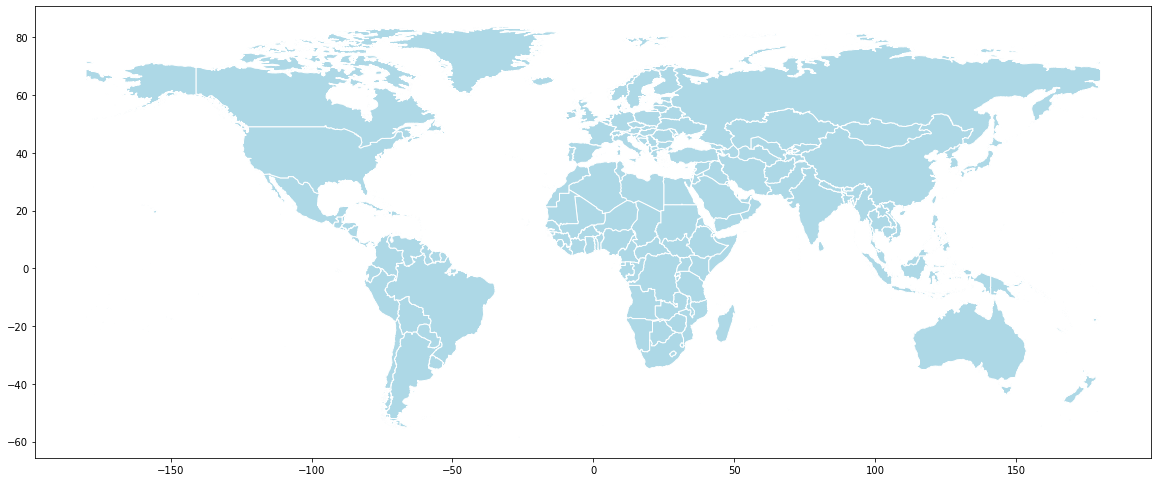

In [5]:
# Drop row for 'Antarctica'. It takes a lot of space in the map and is not of much use
geo_df = geo_df.drop(geo_df.loc[geo_df['COUNTRY'] == 'Antarctica'].index)
geo_df.reset_index(drop=True, inplace=True)

geo_df.plot(figsize=(20, 20), edgecolor='white', linewidth=1, color='lightblue')

In [6]:
def format_as_superscript(number):
    log_output = math.log10(number)

    # Check if log_output is a floating-point number
    if log_output.is_integer():
        superscript_exponent = ''.join(chr(0x2070 + int(digit)) for digit in str(int(log_output)))
    else:
        log_output=round(log_output,2)
        superscript_exponent = ''.join(chr(0x2070 + int(digit)) for digit in str(int(log_output)))

    formatted_text = f"10{superscript_exponent}"
    return formatted_text


In [7]:
pop_countries_geo = geo_df['ISO']

countries = {}
for country in pycountry.countries:
    countries[country.alpha_2] = country.alpha_3


codes_pop_geo = [countries.get(country, 'Unknown code:'+country) for country in pop_countries_geo]

iso3s_pop_geo=[]

for i in pop_countries_geo:
    try:
        iso3s_pop_geo+=[countries[i]]
    except:
        iso3s_pop_geo+=[None]
        
geo_df['ISO3']=iso3s_pop_geo


print(np.unique(codes_pop_geo)) 

['ABW' 'AFG' 'AGO' 'AIA' 'ALB' 'AND' 'ARE' 'ARG' 'ARM' 'ASM' 'ATF' 'ATG'
 'AUS' 'AUT' 'AZE' 'BDI' 'BEL' 'BEN' 'BES' 'BFA' 'BGD' 'BGR' 'BHR' 'BHS'
 'BIH' 'BLM' 'BLR' 'BLZ' 'BMU' 'BOL' 'BRA' 'BRB' 'BRN' 'BTN' 'BVT' 'BWA'
 'CAF' 'CAN' 'CCK' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COD' 'COG' 'COK' 'COL'
 'COM' 'CPV' 'CRI' 'CUB' 'CUW' 'CXR' 'CYM' 'CYP' 'CZE' 'DEU' 'DJI' 'DMA'
 'DNK' 'DOM' 'DZA' 'ECU' 'EGY' 'ERI' 'ESP' 'EST' 'ETH' 'FIN' 'FJI' 'FLK'
 'FRA' 'FRO' 'FSM' 'GAB' 'GBR' 'GEO' 'GGY' 'GHA' 'GIB' 'GIN' 'GLP' 'GMB'
 'GNB' 'GNQ' 'GRC' 'GRD' 'GRL' 'GTM' 'GUF' 'GUM' 'GUY' 'HMD' 'HND' 'HRV'
 'HTI' 'HUN' 'IDN' 'IMN' 'IND' 'IOT' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA'
 'JAM' 'JEY' 'JOR' 'JPN' 'KAZ' 'KEN' 'KGZ' 'KHM' 'KIR' 'KNA' 'KOR' 'KWT'
 'LAO' 'LBN' 'LBR' 'LBY' 'LCA' 'LIE' 'LKA' 'LSO' 'LTU' 'LUX' 'LVA' 'MAF'
 'MAR' 'MCO' 'MDA' 'MDG' 'MDV' 'MEX' 'MHL' 'MKD' 'MLI' 'MLT' 'MMR' 'MNE'
 'MNG' 'MNP' 'MOZ' 'MRT' 'MSR' 'MTQ' 'MUS' 'MWI' 'MYS' 'MYT' 'NAM' 'NCL'
 'NER' 'NFK' 'NGA' 'NIC' 'NIU' 'NLD' 'NOR' 'NPL' 'N

In [10]:
full_df = pd.read_csv('Supplementary Spreadsheet- Incidence Estimates.csv')

df_2010 = full_df[full_df['Year'] == 2010]
df_2025 = full_df[full_df['Year'] == 2025]

cols = ['Country',
    'ISO3',
    'Animal',
    'Disease',
    'Incidence (Cases per 100,000)',
    'Source'
]
df_2010_sel = df_2010[cols]
df_2025_sel = df_2025[cols]

merged = pd.merge(
    df_2010_sel,
    df_2025_sel,
    on=['ISO3', 'Animal', 'Disease'],
    suffixes=('_2010', '_2025')
)

# Calculate the change
merged['Change in disease incidence'] = (
    merged['Incidence (Cases per 100,000)_2025'] 
    - merged['Incidence (Cases per 100,000)_2010']
)

df_incidence_change = merged[
    ['Country_2010',
        'ISO3',
        'Animal',
        'Disease',
        'Change in disease incidence',
        'Source_2010',
        'Source_2025'
    ]
]



In [11]:
#df_incidence_change.to_csv('change_incidence_2010_to_2025.csv',index=False)

Poultry Newcastle disease (velogenic)


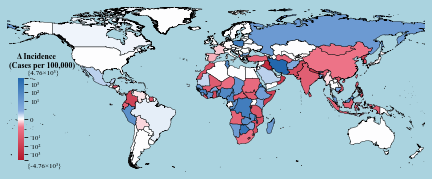

Poultry Infectious bursal disease (Gumboro disease)


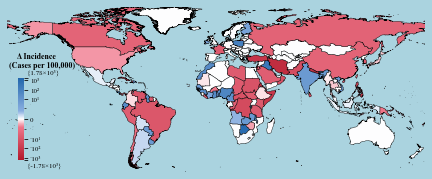

Cattle Anthrax


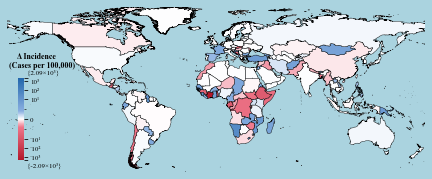

Poultry Avian infectious bronchitis


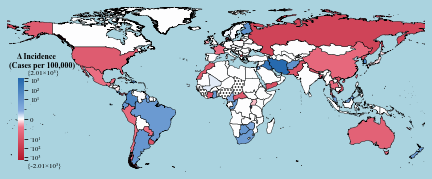

Poultry Marek's disease (-2011)


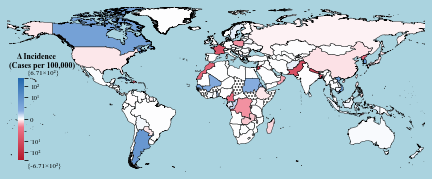

Cattle Rabies virus (Inf. with)


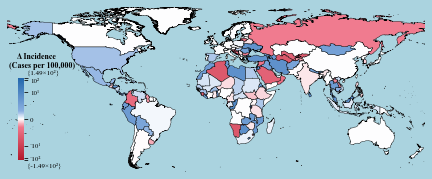

Cattle Foot and mouth disease virus (Inf. with)


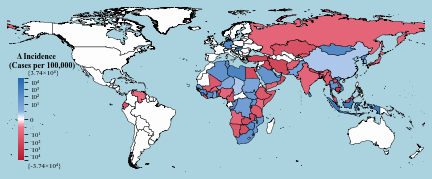

Cattle Lumpy skin disease virus (Inf. with)


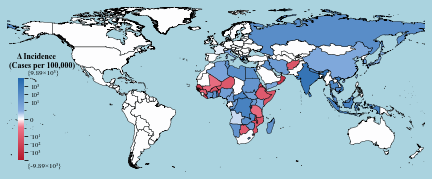

Cattle Brucella abortus (Inf. with)


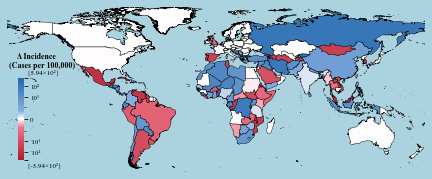

Poultry Avian infectious laryngotracheitis


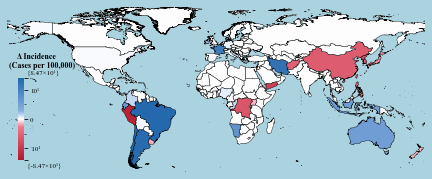

Pigs Classical swine fever virus (Inf. with)


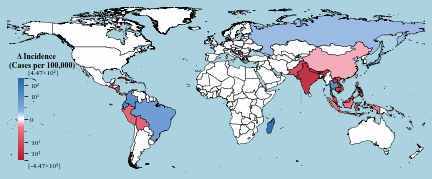

Pigs Anthrax


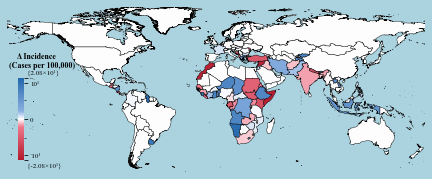

Pigs Rabies virus (Inf. with)


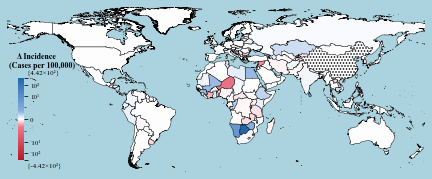

In [13]:
def powers_between(val_1, val_2):
    lower = math.ceil(math.log10(val_1))
    upper = math.floor(math.log10(val_2))
    if math.log10(val_1) % 1 == 0:
        lower += 1
    if math.log10(val_2) % 1 == 0:
        upper -= 1
    return [10**p for p in range(lower, upper+1)]

def print_scientific_notation(value):
    if value == 0:
        return "0"
    exponent = int(math.log10(abs(value)))
    mantissa = value / (10**exponent)
    sign = "⁻" if value < 0 else ""
    sup_map = str.maketrans("0123456789-", "⁰¹²³⁴⁵⁶⁷⁸⁹⁻")
    se = str(exponent).translate(sup_map)
    if abs(mantissa) == 1:
        return f"{sign}10{se}"
    return f"{mantissa:.2f}×10{se}"

plt.rcParams["font.family"] = "Times New Roman"
background_color = (170/255, 211/255, 223/255)
outdir = "2010-2025 change incidence maps"
os.makedirs(outdir, exist_ok=True)

animals = [i[0] for i in top_vaccines]
animals = ['Pigs' if i=='Swine' else i for i in animals]
vaccines = [i[1] for i in top_vaccines]

for animal, disease in zip(animals[0:10] + animals[14:17],
                           vaccines[0:10] + vaccines[14:17]):

    plot_df = df_incidence_change[
        (df_incidence_change['Animal'] == animal) &
        (df_incidence_change['Disease'] == disease)
    ].copy()
    merged_df = pd.merge(geo_df, plot_df, on='ISO3', how='left')

    col = 'Change in disease incidence'
    raw_min, raw_max = merged_df[col].min(), merged_df[col].max()
    bound = max(abs(raw_min), abs(raw_max))
    vmin, vmax = -bound, bound

    # Symmetric log norm
    norm = SymLogNorm(linthresh=1, base=10, vmin=vmin, vmax=vmax)

    # custom red-gray-blue cmap
    cmap_rbgray = LinearSegmentedColormap.from_list(
        "rb_gray",
        [
            (0.00, "#b2182b"),  # deep red
            (0.40, "#ef768a"),  # soft red
            (0.50, "#ffffff"),  # light gray at zero
            (0.60, "#88aee0"),  # soft blue
            (1.00, "#2166ac"),  # deep blue
        ],
        N=256
    )
    cmap = cmap_rbgray

    # setup figure
    fig, ax = plt.subplots(figsize=(6.31*1.3, 5.29/3*1.3),
                           facecolor=background_color)
    ax.set_facecolor('lightseagreen')
    ax.axis('off')

    # plot data
    merged_df.plot(column=col, cmap=cmap, norm=norm,
                   ax=ax, edgecolor='black', linewidth=0.4,
                   missing_kwds={'color': (242/255,239/255,233/255)})

    # overlay missing 
    missing_df = merged_df[merged_df[col].isna()]
    missing_df.plot(
        ax=ax,
        facecolor='white',        
        edgecolor='black',
        linewidth=0.2,
        hatch='....',               
        zorder=6
    )

    # tighten map
    ax.set_xlim(merged_df.total_bounds[0], merged_df.total_bounds[2])
    ax.set_ylim(merged_df.total_bounds[1], merged_df.total_bounds[3])
    ax.set_aspect('equal')
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

    # colorbar
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cax = fig.add_axes([0.165, 0.07, 0.01, 0.5])
    color_bar = fig.colorbar(sm, cax=cax)
    color_bar.outline.set_visible(False)
    color_bar.ax.set_title(
        'Δ Incidence      \n(Cases per 100,000)',
        y=1.05, x=4, weight='bold', fontsize=8
    )

    # ticks at log powers
    pos_powers = powers_between(1, bound) if bound >= 10 else []
    neg_powers = [-p for p in reversed(pos_powers)]
    tick_values = [vmin] + neg_powers + [0] + pos_powers + [vmax]
    color_bar.set_ticks(tick_values)
    labels = [print_scientific_notation(tv) for tv in tick_values]
    color_bar.set_ticklabels(labels)
    color_bar.ax.tick_params(labelsize=7, pad=2)

    

    # relabel top if crowded
    if len(tick_values) > 1 and abs(tick_values[-1] - tick_values[-2]) / abs(tick_values[-1]) <= 1:
        # remove last label
        labels[-1] = ''
        color_bar.set_ticklabels(labels)
        # compute text position
        tpos = color_bar.ax.get_yticks()[-1]
        trans = color_bar.ax.transData.transform
        inv = color_bar.ax.transAxes.inverted().transform
        y = inv(trans((0, tpos)))[1] + 0.06
        color_bar.ax.text(1.5, y,
                          '{' + print_scientific_notation(vmax) + '}',
                          ha='left', va='center',
                          fontsize=7,
                          fontname='Times New Roman',
                          transform=color_bar.ax.transAxes,
                          bbox=dict(boxstyle="round,pad=0.0",
                                    facecolor=background_color,
                                    alpha=0.6,
                                    edgecolor='none'))

    # relabel bottom if crowded
    if len(tick_values) > 1 and abs(tick_values[1] - tick_values[0]) / abs(tick_values[0] if tick_values[0]!=0 else tick_values[1]) <= 1:
        # remove first label
        labels[0] = ''
        color_bar.set_ticklabels(labels)
        tpos = color_bar.ax.get_yticks()[0]
        trans = color_bar.ax.transData.transform
        inv = color_bar.ax.transAxes.inverted().transform
        y = inv(trans((0, tpos)))[1] - 0.06
        color_bar.ax.text(1.5, y,
                          '{' + print_scientific_notation(vmin) + '}',
                          ha='left', va='center',
                          fontsize=7,
                          fontname='Times New Roman',
                          transform=color_bar.ax.transAxes,
                          bbox=dict(boxstyle="round,pad=0.0",
                                    facecolor=background_color,
                                    alpha=0.6,
                                    edgecolor='none'))

    # Give every tick label a light-blue background
    for txt in color_bar.ax.get_yticklabels():
        txt.set_bbox({
            "boxstyle": "round,pad=0.2",
            "facecolor": background_color, 
            "edgecolor": "none",
            "alpha": 1.0
        })
    fname = f"{animal}_{disease}"
    plt.savefig(f"{outdir}/{fname}.svg", format='svg',
                facecolor=background_color, bbox_inches='tight',
                pad_inches=0, dpi=600)
    plt.savefig(f"{outdir}/{fname}.png", format='png',
                facecolor=background_color, bbox_inches='tight',
                pad_inches=0, dpi=600)
    print(animal, disease)
    plt.show()
